<a href="https://colab.research.google.com/github/DSPL-B17/DSPL_hotelchainA/blob/main/Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Reservation Status Prediction - Random Forest Classifier

## Step 1 - Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Libraries imported.')

Libraries imported.


## Step 2 - Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_df = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/train_cleaned.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/validation_cleaned.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/test_cleaned.csv')

print(f'Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}')
train_df.head()

Mounted at /content/drive
Train: (27499, 40) | Val: (2749, 38) | Test: (4318, 36)


,gender,age,ethnicity,educational_level,income,country_region,hotel_type,expected_checkin,expected_checkout,booking_date,...,Checkin_Month,Checkin_DayOfWeek,Is_Weekend_Checkin,Checkin_Season,Total_Guests,Is_Family,Guest_Type,income_enc,education_enc,Capacity_Exceeded
0,F,40,Latino,Grad,<25K,North,City Hotel,2015-07-01,2015-07-02,2015-05-21,...,7,2,0,Summer,4.0,1,Family,0.0,3,0
1,F,49,Latino,Mid-School,50K-100K,East,City Hotel,2015-07-01,2015-07-02,2015-05-26,...,7,2,0,Summer,6.0,1,Family,NaN,0,1
2,F,42,Caucasian,Grad,<25K,East,City Hotel,2015-07-02,2015-07-06,2015-06-29,...,7,3,0,Summer,6.0,1,Family,0.0,3,1
3,M,25,African American,College,>100K,South,Airport Hotels,2015-07-02,2015-07-03,2015-06-20,...,7,3,0,Summer,7.0,1,Family,3.0,2,1
4,F,62,Latino,High-School,25K-50K,East,Resort,2015-07-03,2015-07-04,2015-06-20,...,7,4,0,Summer,2.0,1,Family,NaN,1,0


## Step 2b - Check Column Mismatches

In [ ]:
print('In train, not in val  :', set(train_df.columns) - set(val_df.columns))
print('In train, not in test :', set(train_df.columns) - set(test_df.columns))

In train, not in val  : {'age_group', 'is_lost_booking'}
In train, not in test : {'Revenue_Loss', 'reservation_status', 'age_group', 'is_lost_booking'}


## Step 3 - Define Features and Target

In [ ]:
TARGET = 'reservation_status'

DROP_COLS = [
    'reservation-id',
    'expected_checkin', 'expected_checkout', 'booking_date',
    'Revenue_Loss', 'lead_time_group', 'is_canceled',
    'reservation_status',
]

FEATURES = [c for c in test_df.columns if c not in DROP_COLS]
print(f'Features used: {len(FEATURES)}')

X_train_raw = train_df[FEATURES].copy()
y_train     = train_df[TARGET].copy()
X_val_raw   = val_df[FEATURES].copy()
y_val       = val_df[TARGET].copy()
X_test_raw  = test_df[FEATURES].copy()

print(f'Train: {len(X_train_raw):,} | Val: {len(X_val_raw):,} | Test: {len(X_test_raw):,}')

Features used: 33
Train: 27,499 | Val: 2,749 | Test: 4,318


## Step 4 - Class Distribution

  canceled: 4,134 (15.0%)
  checkout: 21,240 (77.2%)
  no-show: 2,125 (7.7%)


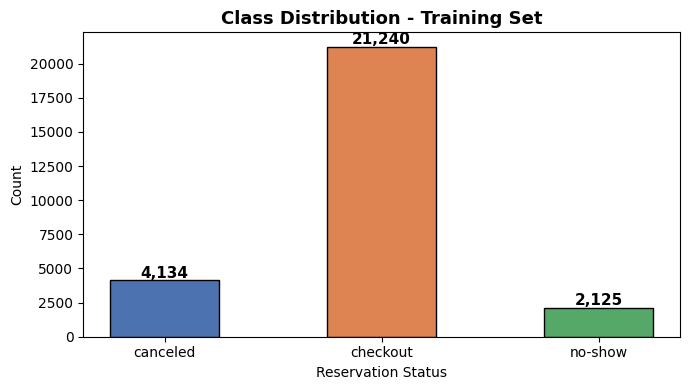

In [ ]:
counts = y_train.value_counts().sort_index()
pct    = y_train.value_counts(normalize=True).sort_index() * 100

for cls in counts.index:
    print(f'  {cls}: {counts[cls]:,} ({pct[cls]:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=['#4C72B0','#DD8452','#55A868'], edgecolor='black', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{v:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution - Training Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Reservation Status')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 - Hyperparameter Tuning with Validation Set

In [ ]:
# max_depth=None removed to prevent overfitting
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [6, 8, 10, 12, 15],
    'min_samples_leaf':  [15, 20, 30, 50],
    'min_samples_split': [20, 30, 50],
    'max_features':      ['sqrt', 'log2', 0.3],
}

base_rf = RandomForestClassifier(class_weight='balanced', oob_score=True, random_state=42, n_jobs=-1)

print('Param grid ready. Tuning will use the actual validation set.')

Param grid ready. Tuning will use the actual validation set.


## Step 6 - Train Model and Make Predictions

In [ ]:
cat_cols = X_train_raw.select_dtypes(include='object').columns.tolist()

X_train = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_val   = pd.get_dummies(X_val_raw,   columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test_raw,  columns=cat_cols, drop_first=True)

# Align val and test columns to match train
X_train, X_val  = X_train.align(X_val,  join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

# Combine train and val for PredefinedSplit
X_combined = pd.concat([X_train, X_val]).reset_index(drop=True)
y_combined = pd.concat([y_train, y_val]).reset_index(drop=True)

# -1 = train rows, 0 = val rows
split_index = np.concatenate([np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)])
ps = PredefinedSplit(test_fold=split_index)

search = RandomizedSearchCV(
    base_rf, param_dist,
    n_iter=30, cv=ps, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1, refit=False
)
search.fit(X_combined, y_combined)

print(f'Best val accuracy: {search.best_score_:.4f}')
print('Best params:', search.best_params_)

# Refit best model on train only
best_rf = RandomForestClassifier(
    **search.best_params_,
    class_weight='balanced', oob_score=True, random_state=42, n_jobs=-1
)
best_rf.fit(X_train, y_train)

y_train_pred = best_rf.predict(X_train)
y_val_pred   = best_rf.predict(X_val)
y_test_pred  = best_rf.predict(X_test)
print('Predictions done.')

X_train: (27499, 46) | X_val: (2749, 46) | X_test: (4318, 46)
Fitting 1 folds for each of 30 candidates, totalling 30 fits
Best val accuracy: 0.4769
Best params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': 'log2', 'max_depth': 15}
Predictions done.


## Step 7 - Evaluate Model

In [ ]:
train_acc  = accuracy_score(y_train, y_train_pred)
val_acc    = accuracy_score(y_val,   y_val_pred)
oob        = best_rf.oob_score_
gap        = train_acc - val_acc

print(f'Train Accuracy : {train_acc:.4f}')
print(f'Val Accuracy   : {val_acc:.4f}')
print(f'OOB Score      : {oob:.4f}')
print(f'Gap            : {gap:+.4f}')
print()

if gap > 0.10:
    print('Overfit - trees too deep')
elif gap > 0.05:
    print('Mild overfit - slight regularization needed')
elif val_acc < 0.65:
    print('Underfit - model too simple or needs more features')
else:
    print('Good fit')

summary = pd.DataFrame({'Split': ['Train', 'Validation', 'OOB'], 'Accuracy': [train_acc, val_acc, oob]})
print()
print(summary.to_string(index=False))

Train Accuracy : 0.8135
Val Accuracy   : 0.4769
OOB Score      : 0.6581
Gap            : +0.3366

Overfit - trees too deep

     Split  Accuracy
     Train  0.813520
Validation  0.476901
       OOB  0.658097


## Step 8 - Confusion Matrix

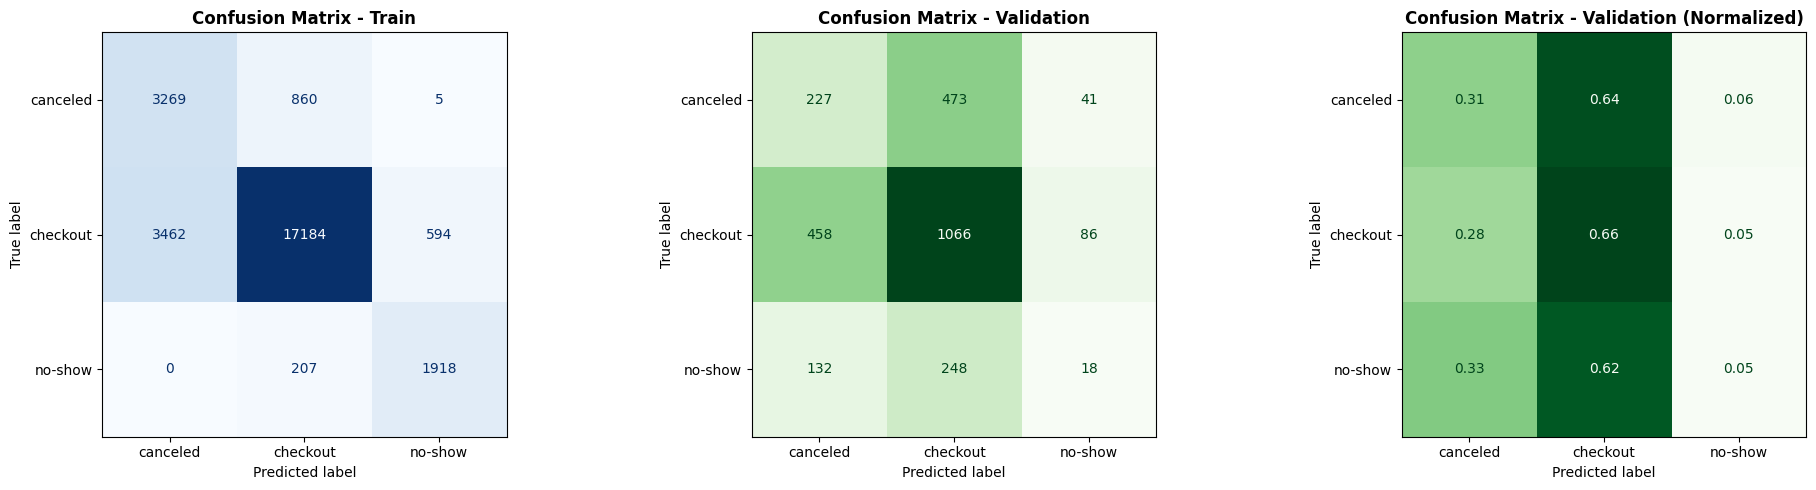

In [ ]:
class_labels = sorted(y_train.unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_train = confusion_matrix(y_train, y_train_pred, labels=class_labels)
ConfusionMatrixDisplay(cm_train, display_labels=class_labels).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix - Train', fontsize=12, fontweight='bold')

cm_val = confusion_matrix(y_val, y_val_pred, labels=class_labels)
ConfusionMatrixDisplay(cm_val, display_labels=class_labels).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix - Validation', fontsize=12, fontweight='bold')

cm_val_norm = confusion_matrix(y_val, y_val_pred, labels=class_labels, normalize='true')
ConfusionMatrixDisplay(cm_val_norm.round(2), display_labels=class_labels).plot(ax=axes[2], colorbar=False, cmap='Greens')
axes[2].set_title('Confusion Matrix - Validation (Normalized)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 - Feature Importance

Top 15 Features:
Lead_Time            0.135336
Net_Revenue          0.073557
Gross_Revenue        0.072691
room_rate            0.070780
age                  0.065767
meal_type_FB         0.055138
Checkin_Month        0.043966
Checkin_DayOfWeek    0.037178
discount_rate        0.035694
Total_Guests         0.030124
adults               0.022559
education_enc        0.021087
meal_type_HB         0.020154
children             0.017987
Length_of_Stay       0.017637


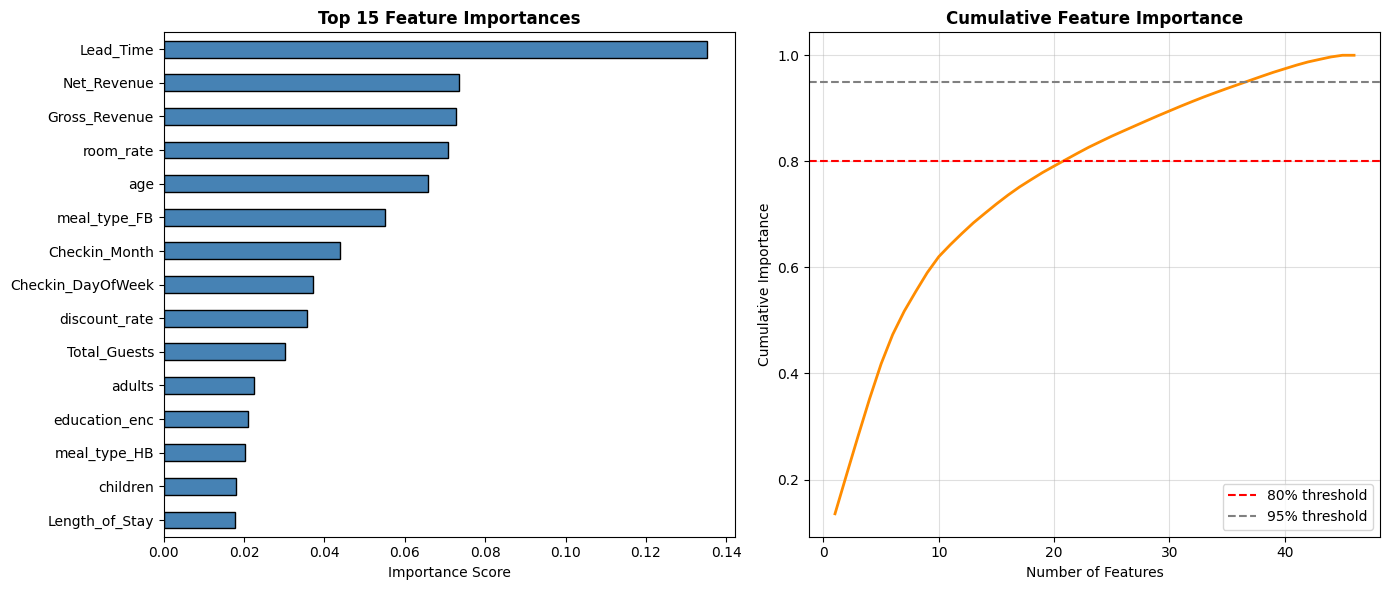

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print('Top 15 Features:')
print(importances.head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

importances.head(15).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')

cumulative = importances.cumsum()
axes[1].plot(range(1, len(cumulative)+1), cumulative.values, color='darkorange', linewidth=2)
axes[1].axhline(0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(0.95, color='gray', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 - Classification Report

In [ ]:
class_labels = sorted(y_train.unique())

print('Train Set')
print('=' * 55)
print(classification_report(y_train, y_train_pred, target_names=[str(l) for l in class_labels]))

print('Validation Set')
print('=' * 55)
print(classification_report(y_val, y_val_pred, target_names=[str(l) for l in class_labels]))

Train Set
              precision    recall  f1-score   support

    canceled       0.49      0.79      0.60      4134
    checkout       0.94      0.81      0.87     21240
     no-show       0.76      0.90      0.83      2125

    accuracy                           0.81     27499
   macro avg       0.73      0.83      0.77     27499
weighted avg       0.86      0.81      0.83     27499

Validation Set
              precision    recall  f1-score   support

    canceled       0.28      0.31      0.29       741
    checkout       0.60      0.66      0.63      1610
     no-show       0.12      0.05      0.07       398

    accuracy                           0.48      2749
   macro avg       0.33      0.34      0.33      2749
weighted avg       0.44      0.48      0.46      2749



## Step 11 - Learning Curves

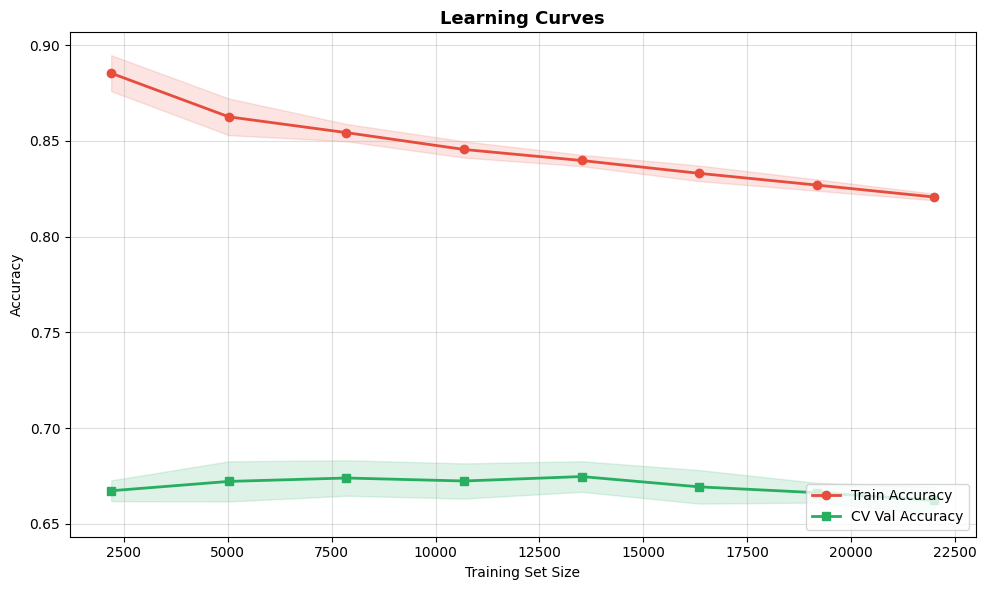

Train: 0.8206 | CV Val: 0.6622 | Gap: +0.1584


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train,
    train_sizes  = np.linspace(0.1, 1.0, 8),
    cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring      = 'accuracy',
    n_jobs       = -1,
    shuffle      = True,
    random_state = 42,
)

tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, tm, 'o-', color='#E74C3C', linewidth=2, label='Train Accuracy')
plt.plot(train_sizes, vm, 's-', color='#27AE60', linewidth=2, label='CV Val Accuracy')
plt.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.15, color='#E74C3C')
plt.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.15, color='#27AE60')
plt.title('Learning Curves', fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Train: {tm[-1]:.4f} | CV Val: {vm[-1]:.4f} | Gap: {tm[-1]-vm[-1]:+.4f}')

## Step 12 - Save Test Predictions

In [ ]:
if 'reservation-id' in test_df.columns:
    reservation_ids = test_df['reservation-id']
else:
    reservation_ids = test_df.index

test_preds_df = pd.DataFrame({
    'reservation-id': reservation_ids,
    'predicted_reservation_status': y_test_pred,
})
test_preds_df.to_csv('/content/drive/MyDrive/DSPL/GCW/Data/Outputs/Final_Model_test_predictions.csv', index=False)

print('Predictions saved to test_predictions.csv')
print(pd.Series(y_test_pred).value_counts().to_string())
test_preds_df.head()

Predictions saved to test_predictions.csv
checkout    2520
canceled    1548
no-show      250


,reservation-id,predicted_reservation_status
0,0,checkout
1,1,canceled
2,2,checkout
3,3,canceled
4,4,checkout


## Step 13 - Save Model

In [ ]:
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print('Model saved.')
print(f'Train: {train_acc:.4f} | Val: {val_acc:.4f} | OOB: {oob:.4f} | Gap: {gap:+.4f}')
print('Best Params:', search.best_params_)

Model saved.
Train: 0.8135 | Val: 0.4769 | OOB: 0.6581 | Gap: +0.3366
Best Params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': 'log2', 'max_depth': 15}
